In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import time
from typing import Sequence, Tuple
import numpy as np
import jax
import jax.numpy as jnp
from jaxued.environments.underspecified_env import EnvParams, EnvState, UnderspecifiedEnv
from jaxued.utils import compute_max_mean_returns_epcount
import optax
from flax import struct
from flax.training.train_state import TrainState as BaseTrainState
import flax.linen as nn
from flax.linen.initializers import constant, orthogonal
import distrax
import orbax.checkpoint as ocp
import wandb
from jaxued.environments.maze.env_editor import MazeEditor, Observation, ObservedMazeEditor, ObservedMazeEditorWithGoal
from jaxued.linen import ResetRNN
from jaxued.environments import Maze, MazeRenderer, ObservedMazeRenderer
from jaxued.environments.maze import Level, ObservedLevel
from jaxued.wrappers import AutoReplayWrapper
import chex

import logging
import hydra
from omegaconf import DictConfig, OmegaConf
import matplotlib.pyplot as plt

logger = logging.getLogger(__name__)

In [3]:
from omegaconf import OmegaConf
from hydra import initialize, compose


def load_hydra_config(config_path, config_name):
    # Initialize the Hydra context
    with initialize(config_path=config_path):
        # Compose the configuration
        cfg = compose(config_name=config_name)
        return cfg
    
config_path = "config"  # path to the directory containing the config file
config_name = "main_paired"  # name of the config file without the extension

config = load_hydra_config(config_path, config_name)

if config["num_env_steps"] is not None:
    config["num_updates"] = config["num_env_steps"] // (config["num_train_envs"] * config["num_steps"])

if config['mode'] == 'eval':
    os.environ['WANDB_MODE'] = 'disabled'
    

/tmp/ipykernel_61646/2007320477.py:7: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  with initialize(config_path=config_path):


In [4]:
env = Maze(max_height=13, max_width=13, agent_view_size=5, normalize_obs=True)
adv_env = ObservedMazeEditorWithGoal(env, random_z_dimensions=config['adv_random_z_dimension'], zero_out_random_z=config['adv_zero_out_random_z'])
adv_env_renderer = ObservedMazeRenderer(env, tile_size=8)
env_renderer = MazeRenderer(env, tile_size=8)
env = AutoReplayWrapper(env)
env_params = env.default_params
adv_env_params = adv_env.default_params

def sample_empty_level():
    w, h = env._env.max_width, env._env.max_height
    return ObservedLevel(
        wall_map=jnp.zeros((h, w), dtype=jnp.bool_),
        observation_map=jnp.zeros((h, w), dtype=jnp.bool_),
        width=w,
        height=h,
        
        # These values don't matter, as the adversary overwrites them.
        goal_pos=jnp.array([0, 0], dtype=jnp.uint32),
        agent_pos=jnp.array([1, 1], dtype=jnp.uint32),
        agent_dir=jnp.array(0, dtype=jnp.uint8),
        goal_placed=jnp.array(False, dtype=jnp.bool_),
    )

rng = jax.random.PRNGKey(14532)
rng, _rng = jax.random.split(rng)

# Adversary Env

In [7]:
# adversary
rng, _rng = jax.random.split(rng)
init_adv_obs, init_adv_env_state = adv_env.reset_to_level(_rng, sample_empty_level(), adv_env_params)
adv_state = init_adv_env_state

# place goal, agent direction, place agent
for action in [169*3 - 1, 3]:
    rng, _rng = jax.random.split(rng)
    adv_obs, adv_next_state, adv_reward, adv_done, _ = adv_env.step(_rng, adv_state, action, env_params)
    adv_state = adv_next_state

# agent
rng, _rng = jax.random.split(rng)
obs, init_env_state = env.reset_to_level(_rng, adv_state.level, adv_env_params)
state = init_env_state

In [8]:
obs

Observation(image=Array([[[0.1, 0. , 0. ],
        [0.1, 0. , 0. ],
        [0.1, 0. , 0. ],
        [0.1, 0. , 0. ],
        [0.1, 0. , 0. ]],

       [[0.1, 0. , 0. ],
        [0.1, 0. , 0. ],
        [0.1, 0. , 0. ],
        [0.1, 0. , 0. ],
        [0.1, 0. , 0. ]],

       [[0.1, 0. , 0. ],
        [0.1, 0. , 0. ],
        [0.1, 0. , 0. ],
        [0.1, 0. , 0. ],
        [0.1, 0. , 0. ]],

       [[0.2, 0.5, 0. ],
        [0.2, 0.5, 0. ],
        [0.2, 0.5, 0. ],
        [0.2, 0.5, 0. ],
        [0.2, 0.5, 0. ]],

       [[0.2, 0.5, 0. ],
        [0.2, 0.5, 0. ],
        [0.2, 0.5, 0. ],
        [0.2, 0.5, 0. ],
        [0.2, 0.5, 0. ]]], dtype=float32, weak_type=True), agent_dir=Array(3, dtype=uint8), obs_location=Array([[[0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [

In [30]:
# adversary
rng, _rng = jax.random.split(rng)
adv_obs, adv_next_state, adv_reward, adv_done, _ = adv_env.step(_rng, adv_state, 122 + 169*1, env_params)
adv_state = adv_next_state

# update agent
obs, state = env.update_state_from_level(adv_state.level, state)

In [54]:
# agent
rng, _rng = jax.random.split(rng)
obs, next_state, reward, done, _ = env.step(rng, state, 3, env_params)
state = next_state

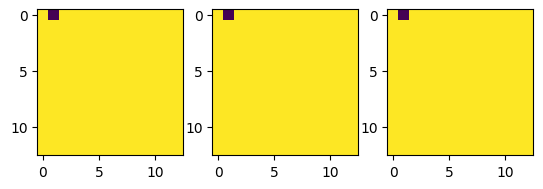

In [47]:
action_mask = adv_obs.action_mask.reshape(3, 13, 13)

fig, axes = plt.subplots(1, 3)

for i, ax in enumerate(axes):
    ax.imshow(action_mask[i])

In [47]:
obs.image[:, :, 0]

Array([[0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.1, 0.8, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, 0.1, 0.1]], dtype=float32, weak_type=True)

In [38]:
state.env_state.goal_pos

Array([0, 0], dtype=uint32)

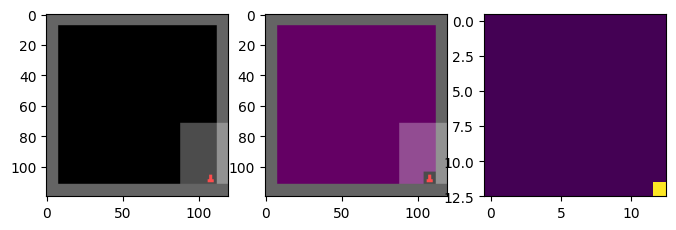

In [9]:
state_image = env_renderer.render_state(state.env_state, env_params)
adv_state_image = adv_env_renderer.render_state(adv_state.level, env_params)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 4))
ax1.imshow(state_image)
ax2.imshow(adv_state_image)
ax3.imshow(adv_state.level.observation_map)

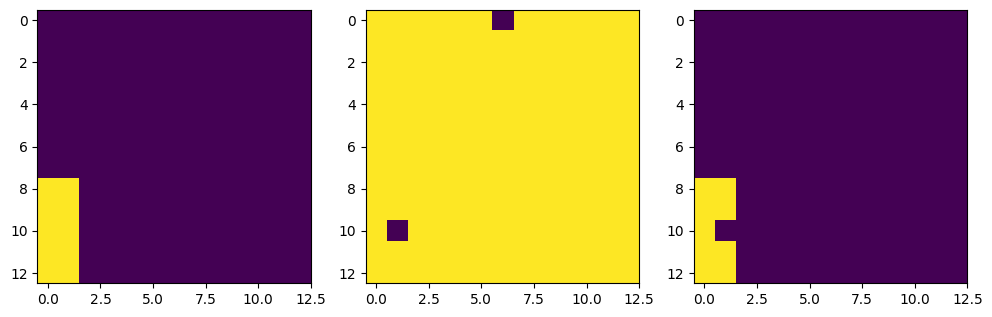

In [7]:
obs.obs_location
possible_actions = obs.obs_location[4:-4, 4:-4].squeeze() != 0
available_actions = jnp.logical_and(possible_actions, ~adv_state.level.observation_map)

action_mask = jnp.stack([available_actions, available_actions]).flatten()

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.imshow(possible_actions)
ax2.imshow(~adv_state.level.observation_map)
ax3.imshow(available_actions)

In [203]:
init_obs, init_env_state = env.reset_to_level(_rng, adv_state.level, adv_env_params)
state = init_env_state

In [210]:
obs, next_state, reward, done, _ = env.step(rng, state, 2, env_params)
state = next_state

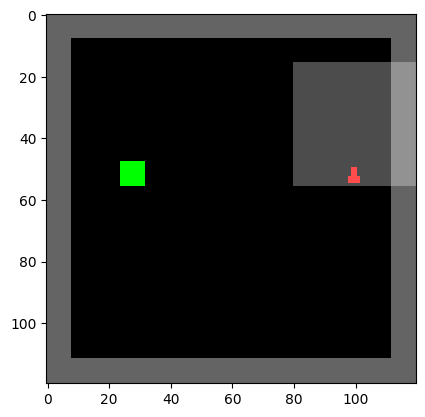

In [211]:
state_image = env_renderer.render_state(state.env_state, env_params)
plt.imshow(state_image)

# Agent Env

In [123]:
rng_pro, rng_ant, rng_adv = jax.random.split(rng, 3)
adv_train_state = create_inner_train_state(rng_adv, adv_env, adv_env_params, AdversaryActorCritic, "adv_", network_kws={"max_timesteps": config["adv_num_steps"]})


empty_levels = jax.tree.map(lambda x: jnp.array([x]).repeat(config["num_train_envs"], axis=0), sample_empty_level())

init_obs, init_env_state = jax.vmap(env.reset_to_level, in_axes=(0, 0, None))(jax.random.split(_rng, config["num_train_envs"]), empty_levels, env_params)

In [124]:
levels = init_env_state.level

level_images = jax.vmap(env_renderer.render_level, (0, None))(levels, env_params)

level_images.shape

(32, 120, 120, 3)

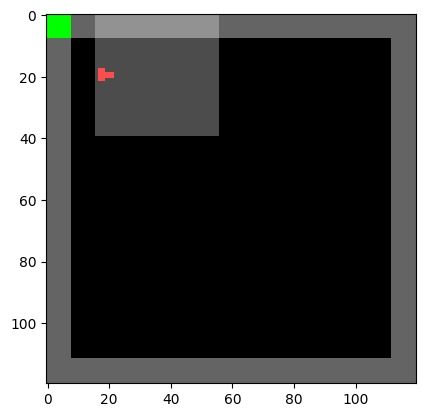

In [125]:
plt.imshow(level_images[0])

In [129]:
rng, _rng = jax.random.split(rng)
init_obs, init_env_state = env.reset_to_level(_rng, sample_empty_level(), env_params)
state = init_env_state
state

AutoReplayState(env_state=EnvState(agent_pos=Array([1, 1], dtype=uint32), agent_dir=Array(0, dtype=uint8), goal_pos=Array([0, 0], dtype=uint32), wall_map=Array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, Fals

In [130]:
obs, next_state, reward, done, _ = env.step(rng, state, 2, env_params)
state = next_state

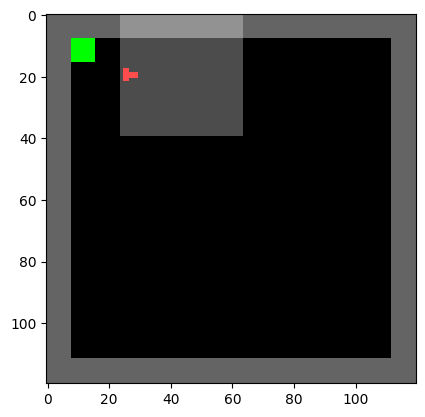

In [131]:
state_image = env_renderer.render_state(state.env_state, env_params)
plt.imshow(state_image)